# Setup

Import all the required libraries and packages

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import PIL
import cv2
import kagglehub
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# set random seeds
np.random.seed(42)
tf.random.set_seed(42)

# **Small Flower Dataset**

# Preprocessing data
Download and extract the flower datasets from TensorFlow

In [2]:
path2 = kagglehub.dataset_download("kausthubkannan/5-flower-types-classification-dataset")
print("Path to dataset files:", path2)

Path to dataset files: /kaggle/input/5-flower-types-classification-dataset


In [3]:
import pathlib

label = []
my_path = []
datalist = os.listdir(path2)

for fold in datalist:
    foldpath = os.path.join(path2,fold)
    foldlist = os.listdir(foldpath)
    for file in foldlist:
        filepath = os.path.join(foldpath,file)
        print(filepath)
        imgs = os.listdir(filepath)
        for img in imgs:
            imgpath = os.path.join(filepath,img)
            label.append(file)
            my_path.append(imgpath)

l = pd.Series(label,name="labels")
p = pd.Series(my_path,name="filepath")
df = pd.concat([p,l],axis=1)
df.head()

/kaggle/input/5-flower-types-classification-dataset/flower_images/Orchid
/kaggle/input/5-flower-types-classification-dataset/flower_images/Sunflower
/kaggle/input/5-flower-types-classification-dataset/flower_images/Tulip
/kaggle/input/5-flower-types-classification-dataset/flower_images/Lotus
/kaggle/input/5-flower-types-classification-dataset/flower_images/Lilly


,filepath,labels
0,/kaggle/input/5-flower-types-classification-da...,Orchid
1,/kaggle/input/5-flower-types-classification-da...,Orchid
2,/kaggle/input/5-flower-types-classification-da...,Orchid
3,/kaggle/input/5-flower-types-classification-da...,Orchid
4,/kaggle/input/5-flower-types-classification-da...,Orchid


In [4]:
df.sample(5)

,filepath,labels
1501,/kaggle/input/5-flower-types-classification-da...,Sunflower
2586,/kaggle/input/5-flower-types-classification-da...,Tulip
2653,/kaggle/input/5-flower-types-classification-da...,Tulip
1055,/kaggle/input/5-flower-types-classification-da...,Sunflower
705,/kaggle/input/5-flower-types-classification-da...,Orchid


In [5]:
df.shape

(5000, 2)

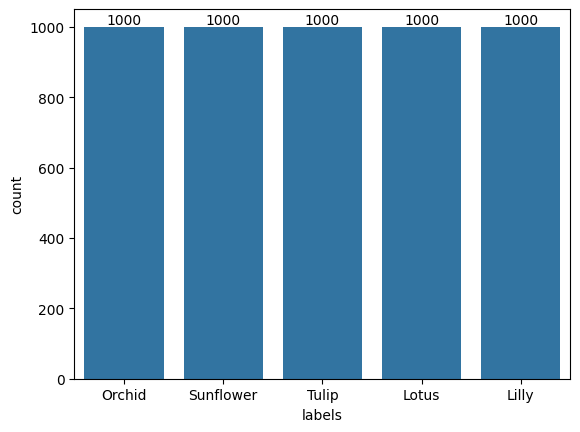

In [6]:
ax = sns.countplot(x=df['labels'])
ax.bar_label(ax.containers[0]);

# Supervised Learning Classification Methods

Create numerical labels

In [7]:
label_encoder = LabelEncoder()
df['encode_label'] = label_encoder.fit_transform(df['labels'])

In [8]:
df.head()

,filepath,labels,encode_label
0,/kaggle/input/5-flower-types-classification-da...,Orchid,2
1,/kaggle/input/5-flower-types-classification-da...,Orchid,2
2,/kaggle/input/5-flower-types-classification-da...,Orchid,2
3,/kaggle/input/5-flower-types-classification-da...,Orchid,2
4,/kaggle/input/5-flower-types-classification-da...,Orchid,2


Resize and normalize the images in the dataset

In [9]:
import cv2

x = []
for img_path in df['filepath']:
    img = cv2.imread(img_path)
    img = cv2.resize(img, (180, 180))   #Resizes the image to a shape of 180x180 using the OpenCV library's resize function
    img = img / 255.0    #Normalizes the pixel values of the image by dividing them by 255.0
    x.append(img)

In [10]:
x = np.array(x)
x.shape

(5000, 180, 180, 3)

In [11]:
y = np.array(df['encode_label'])
y

array([2, 2, 2, ..., 0, 0, 0])

In [12]:
y.shape

(5000,)

Display an image with label

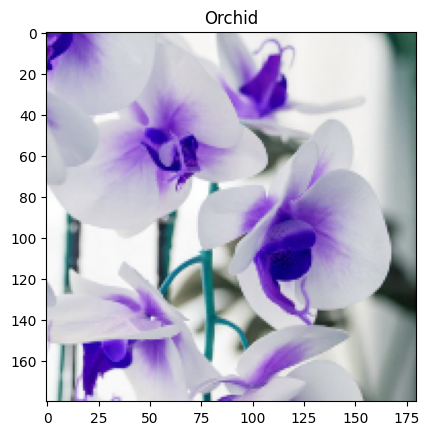

In [13]:
plt.imshow(x[500])
plt.title(label_encoder.classes_[y[500]]);

Convert 2D images to 1D

In [14]:
num_samples, img_height, img_width, num_channels  = x.shape # Get image dimensions
# Flatten each image into a 1D array
x_flattened = x.reshape(num_samples, -1)  # Shape: (num_samples, img_height * img_width * num_channels)

In [15]:
x_flattened.shape

(5000, 97200)

Prepare training and test dataset

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_flattened, y, test_size=.20, random_state=42)

## Dimensionality Reduction using PCA

Choose the right number of dimensions



In [17]:
pca = PCA()
pca.fit(x_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1
d

np.int64(687)

Plot the Cumulative Explained Variance curve

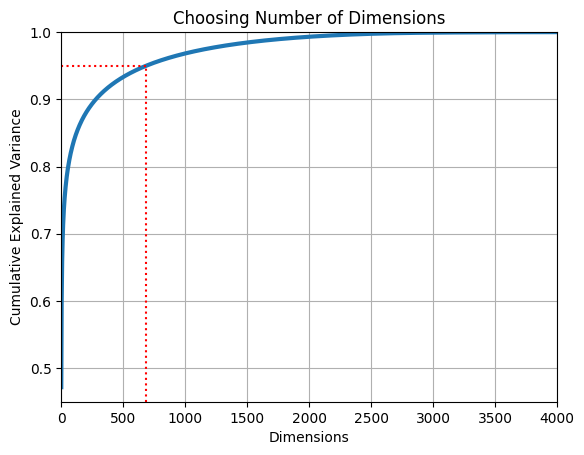

In [18]:
plt.plot(cumsum, linewidth=3)
plt.axis([0, 4000, 0.45, 1])
plt.xlabel('Dimensions')
plt.ylabel('Cumulative Explained Variance')
plt.title('Choosing Number of Dimensions')
plt.plot([d, d], [0.45, 0.95], 'r:')
plt.plot([0, d], [0.95, 0.95], 'r:')
plt.grid()
plt.show()

 Chose and apply the final number of components

In [19]:
pca = PCA(n_components = 687)
X_reduced = pca.fit_transform(x_train)
X_recovered = pca.inverse_transform(X_reduced)
print(f"Final shape after PCA: {X_reduced.shape}")

Final shape after PCA: (4000, 687)


Compare the image before and after reducing dimensions

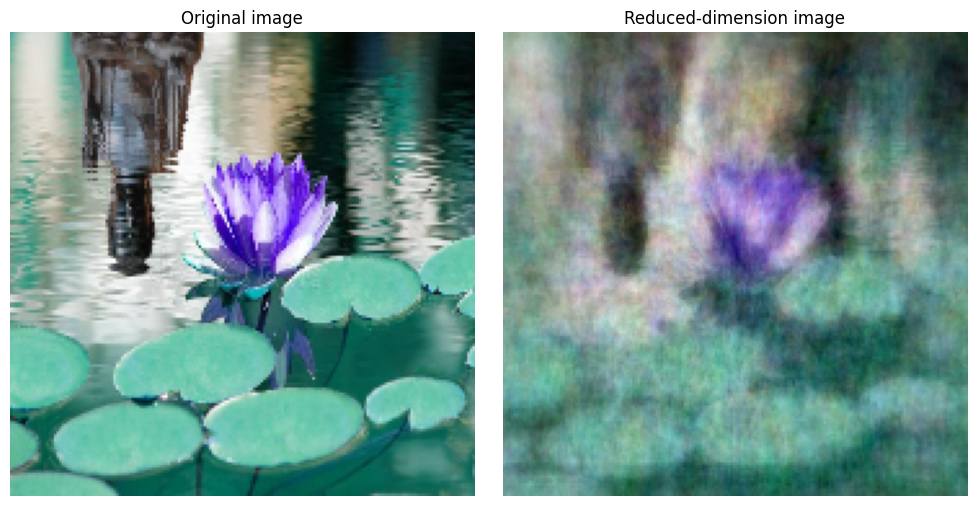

In [20]:
# Reshape the 1D images into 2D color images (180x180x3)
images_2d_train = x_train.reshape(4000, 180, 180, 3)
images_2d_recovered = X_recovered.reshape(4000, 180, 180, 3)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(images_2d_train[2005])
axes[0].axis('off')  # Hide axes for better visualization
axes[0].set_title('Original image')
# Normalize reduced-dimension image to the range [0, 1]
image_rescaled = (images_2d_recovered[2005] - np.min(images_2d_recovered[2005])) / (np.max(images_2d_recovered[2005]) - np.min(images_2d_recovered[2005]))
axes[1].imshow(image_rescaled)
axes[1].axis('off')
axes[1].set_title('Reduced-dimension image')
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

Scale the reduced training data set

In [21]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_reduced.astype(np.float64))

## Train three classifiers using (x_train, y_train)

**Classifier 1: Random Forest**

In [22]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rnd_clf.fit(x_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Display the cross validation result of the Random Forest classifier

In [23]:
from sklearn.model_selection import cross_val_score

cross_val_score(rnd_clf, x_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.65817091, 0.64591148, 0.67591898])

Check the accuracy of the Random Forest classifier

In [24]:
from sklearn.metrics import accuracy_score

x_test_reduced = pca.transform(x_test)  # reduce dimensions of x_test
x_test_scaled = scaler.transform(x_test_reduced.astype(np.float64)) # scale the reduced x_test
y_pred = rnd_clf.predict(x_test_scaled)
print(rnd_clf.__class__.__name__, accuracy_score(y_test, y_pred))

RandomForestClassifier 0.769


Perform grid search for hyperparameter tuning

In [25]:
from sklearn.model_selection import GridSearchCV

rnd_clf = RandomForestClassifier(random_state=42)
# Define the hyperparameter grid
param_grid = {
    # Hyperparameters for RandomForestClassifier
    'n_estimators': [10, 50, 500],  # Number of trees in the forest
    'max_depth': [None, 10],  # Maximum depth of the tree
    'min_samples_split': [20, 50],  # Minimum samples required to split a node
}
# Perform GridSearchCV
rnd_grid_search = GridSearchCV(rnd_clf, param_grid, cv=5, n_jobs=-1, verbose=2)
rnd_grid_search.fit(x_train_scaled, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10], 'min_samples_split': [20, 50],
                         'n_estimators': [10, 50, 500]},
             verbose=2)

The best hyperparameter combination found:

In [26]:
rnd_grid_search.best_params_

{'max_depth': None, 'min_samples_split': 20, 'n_estimators': 500}

Evaluate the model on test data

In [27]:
y_pred = rnd_grid_search.best_estimator_.predict(x_test_scaled)
print(rnd_clf.__class__.__name__, accuracy_score(y_test, y_pred), 'after hyperparameter tuning')

RandomForestClassifier 0.814 after hyperparameter tuning


Confusion matrix

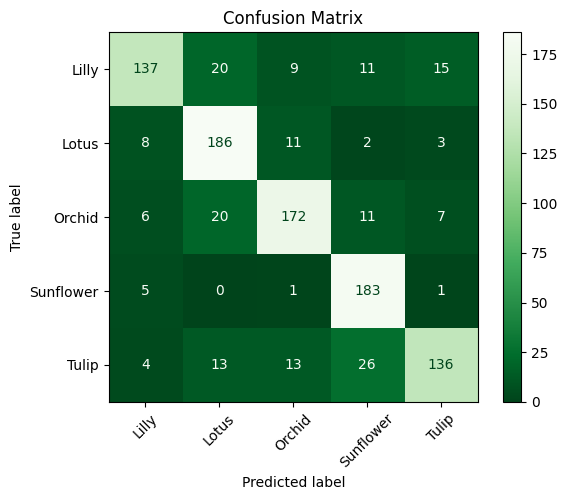

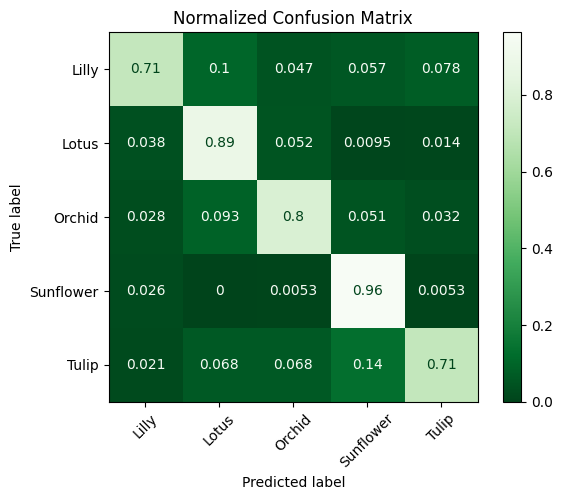

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get class names from the label encoder
class_names = label_encoder.classes_

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Plot normalized confusion matrix
cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()



In [29]:
print("Confusion Matrix (Raw):")
print(cm)

Confusion Matrix (Raw):
[[137  20   9  11  15]
 [  8 186  11   2   3]
 [  6  20 172  11   7]
 [  5   0   1 183   1]
 [  4  13  13  26 136]]


Class 4 (Tulip) is the most confused with other classes, with 56/192 misclassifications in total. It seems particularly confused with Class 3 (Sunflower), with 26/192 misclassifications.

Class 3 (Sunflower) is the least confused with other classes, with 7/190 misclassifications in total.

**Classifier 2: MLP**

In [30]:
from sklearn.neural_network import MLPClassifier

mlp_clf = MLPClassifier(random_state=42)
mlp_clf.fit(x_train_scaled, y_train)

MLPClassifier(random_state=42)

Display the cross validation result of the MLP classifier

In [31]:
cross_val_score(mlp_clf, x_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.60944528, 0.61065266, 0.63615904])

Check the accuracy of the MLP classifier

In [32]:
y_pred = mlp_clf.predict(x_test_scaled)
print(mlp_clf.__class__.__name__, accuracy_score(y_test, y_pred))

MLPClassifier 0.752


Perform grid search for hyperparameter tuning

In [33]:
mlp_clf = MLPClassifier(random_state=42)
param_grid = {
    'hidden_layer_sizes': [(50,), (200,)],  # Number of neurons in hidden layers
    'alpha': [0.001, 0.0001],  # Regularization strength
    'batch_size': ['auto', 64, 128],  # Batch size for sgd and adam
}
mlp_grid_search = GridSearchCV(mlp_clf, param_grid, cv=5, n_jobs=-1, verbose=2)
mlp_grid_search.fit(x_train_scaled, y_train)
mlp_grid_search.best_params_

Fitting 5 folds for each of 12 candidates, totalling 60 fits


{'alpha': 0.0001, 'batch_size': 64, 'hidden_layer_sizes': (200,)}

Evaluate the model on test data

In [34]:
y_pred = mlp_grid_search.best_estimator_.predict(x_test_scaled)
print(mlp_clf.__class__.__name__, accuracy_score(y_test, y_pred), 'after hyperparameter tuning')

MLPClassifier 0.764 after hyperparameter tuning


**Classifier 3: SVM**

In [35]:
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(gamma="auto", random_state=42, probability=True))
ovr_clf.fit(x_train_scaled, y_train)

OneVsRestClassifier(estimator=SVC(gamma='auto', probability=True,
                                  random_state=42))

Display the cross validation result of the SVM classifier

In [36]:
cross_val_score(ovr_clf, x_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.64617691, 0.63090773, 0.66016504])

Check the accuracy of the SVM classifier

In [37]:
y_pred = ovr_clf.predict(x_test_scaled)
print(ovr_clf.__class__.__name__, accuracy_score(y_test, y_pred))

OneVsRestClassifier 0.739


Perform grid search for hyperparameter tuning

In [38]:
ovr_clf = OneVsRestClassifier(SVC(gamma="auto", random_state=42, probability=True))
param_grid = {
    'estimator': [SVC(C=10.0, gamma='scale', probability=True)],
    'n_jobs': [-1],  # The number of jobs to run in parallel for cross-validation
}
ovr_grid_search = GridSearchCV(ovr_clf, param_grid, cv=5, n_jobs=-1, verbose=2)
ovr_grid_search.fit(x_train_scaled, y_train)
ovr_grid_search.best_params_

Fitting 5 folds for each of 1 candidates, totalling 5 fits


{'estimator': SVC(C=10.0, probability=True), 'n_jobs': -1}

Evaluate the model on test data

In [39]:
y_pred = ovr_grid_search.best_estimator_.predict(x_test_scaled)
print(ovr_clf.__class__.__name__, accuracy_score(y_test, y_pred), 'after hyperparameter tuning')

OneVsRestClassifier 0.753 after hyperparameter tuning


Use the best hyperparameter combination of the three classifiers for ensemble methods.

## Ensemble Methods
1. Hard-voting

In [40]:
from sklearn.ensemble import VotingClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, min_samples_split=20)
mlp_clf = MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(50,))
ovr_clf = OneVsRestClassifier(SVC(C=10.0, gamma='scale', probability=True), n_jobs=-1)
voting_clf = VotingClassifier(
    estimators=[('mlp', mlp_clf), ('rf', rnd_clf), ('svc', ovr_clf)],
    voting='hard')
voting_clf.fit(x_train_scaled, y_train)

VotingClassifier(estimators=[('mlp',
                              MLPClassifier(alpha=0.001, batch_size=64,
                                            hidden_layer_sizes=(50,))),
                             ('rf',
                              RandomForestClassifier(min_samples_split=20,
                                                     n_estimators=500)),
                             ('svc',
                              OneVsRestClassifier(estimator=SVC(C=10.0,
                                                                probability=True),
                                                  n_jobs=-1))])

Display the cross validation result of the hard-voting classifier

In [41]:
cross_val_score(voting_clf, x_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.64467766, 0.65266317, 0.67216804])

Check the accuracy of the hard-voting classifier

In [42]:
y_pred = voting_clf.predict(x_test_scaled)
print(voting_clf.__class__.__name__, accuracy_score(y_test, y_pred))

VotingClassifier 0.767


2. Soft-voting

In [43]:
voting_clf = VotingClassifier(
    estimators=[('mlp', mlp_clf), ('rf', rnd_clf), ('svc', ovr_clf)],
    voting='soft')
voting_clf.fit(x_train_scaled, y_train)

VotingClassifier(estimators=[('mlp',
                              MLPClassifier(alpha=0.001, batch_size=64,
                                            hidden_layer_sizes=(50,))),
                             ('rf',
                              RandomForestClassifier(min_samples_split=20,
                                                     n_estimators=500)),
                             ('svc',
                              OneVsRestClassifier(estimator=SVC(C=10.0,
                                                                probability=True),
                                                  n_jobs=-1))],
                 voting='soft')

Display the cross validation result of the soft-voting classifier

In [44]:
cross_val_score(voting_clf, x_train_scaled, y_train, cv=3, scoring="accuracy")

array([0.62743628, 0.62265566, 0.6504126 ])

Check the accuracy of the soft-voting classifier.

In [45]:
y_pred = voting_clf.predict(x_test_scaled)
print(voting_clf.__class__.__name__, accuracy_score(y_test, y_pred))

VotingClassifier 0.757


3. Stacking

We divide the training data into two parts: (X_train, Y_train) and (X_val, Y_val).

In [46]:
X_train = X_reduced[0:3000]
Y_train = y_train[0:3000]
X_val = X_reduced[3000:4000]
Y_val = y_train[3000:4000]

Scale the data set X_train.

In [47]:
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

Train three classifiers using (X_train, Y_train).

Random Forest classifier

In [48]:
rnd_clf = RandomForestClassifier(n_estimators=500, min_samples_split=20)
rnd_clf.fit(X_train_scaled, Y_train)
cross_val_score(rnd_clf, X_train_scaled, Y_train, cv=3, scoring="accuracy")

array([0.634, 0.619, 0.62 ])

Apply predictions on X_val using random forest classifier.

In [49]:
# Scale the data set X_val
X_val_scaled = scaler.transform(X_val.astype(np.float64))
y_val_pred = rnd_clf.predict(X_val_scaled)

MLP classifier

In [50]:
mlp_clf = MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(50,))
mlp_clf.fit(X_train_scaled, Y_train)
cross_val_score(mlp_clf, X_train_scaled, Y_train, cv=3, scoring="accuracy")

array([0.544, 0.557, 0.55 ])

Apply predictions on X_val using MLP classifier.

In [51]:
y_val_pred_mlp = mlp_clf.predict(X_val_scaled)

SVM classifier

In [52]:
ovr_clf = OneVsRestClassifier(SVC(C=10.0, gamma='scale', probability=True), n_jobs=-1)
ovr_clf.fit(X_train_scaled, Y_train)
cross_val_score(ovr_clf, X_train_scaled, Y_train, cv=3, scoring="accuracy")

array([0.542, 0.566, 0.58 ])

Apply predictions on X_val using SVM classifier.

In [53]:
y_val_pred_ovr = ovr_clf.predict(X_val_scaled)

Combine predictions from 3 predictors.

In [54]:
X_stack_pred_training=np.c_[y_val_pred, y_val_pred_mlp, y_val_pred_ovr]
print(X_stack_pred_training.shape)

(1000, 3)


Try random forest as blender.

In [55]:
blending_rnd_clf = RandomForestClassifier(n_estimators=500, min_samples_split=20)
blending_rnd_clf.fit(X_stack_pred_training, Y_val)
cross_val_score(blending_rnd_clf, X_stack_pred_training, Y_val, cv=3, scoring="accuracy")

array([0.71556886, 0.71771772, 0.6966967 ])

Check the accuracy of the random forest blender

In [56]:
y_test_pred_rnd = rnd_clf.predict(x_test_scaled)
y_test_pred_mlp = mlp_clf.predict(x_test_scaled)
y_test_pred_ovr = ovr_clf.predict(x_test_scaled)
X_stack_pred_test = np.c_[y_test_pred_rnd,y_test_pred_mlp,y_test_pred_ovr]
y_test_pred_blending = blending_rnd_clf.predict(X_stack_pred_test)
print(blending_rnd_clf.__class__.__name__, accuracy_score(y_test, y_test_pred_blending))

RandomForestClassifier 0.725


Try MLP as blender

In [57]:
blending_mlp_clf = MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(50,))
blending_mlp_clf.fit(X_stack_pred_training, Y_val)
cross_val_score(blending_mlp_clf, X_stack_pred_training, Y_val, cv=3, scoring="accuracy")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


array([0.72754491, 0.68768769, 0.64564565])

Check the accuracy of the MLP blender

In [58]:
y_test_pred_blending = blending_mlp_clf.predict(X_stack_pred_test)
print(blending_mlp_clf.__class__.__name__, accuracy_score(y_test, y_test_pred_blending))

MLPClassifier 0.705


Try SVM as blender

In [59]:
blending_ovr_clf = OneVsRestClassifier(SVC(C=10.0, gamma='scale', probability=True), n_jobs=-1)
blending_ovr_clf.fit(X_stack_pred_training, Y_val)
cross_val_score(blending_ovr_clf, X_stack_pred_training, Y_val, cv=3, scoring="accuracy")

array([0.71856287, 0.69369369, 0.65765766])

Check the accuracy of the SVM blender

In [60]:
y_test_pred_blending = blending_ovr_clf.predict(X_stack_pred_test)
print(blending_ovr_clf.__class__.__name__, accuracy_score(y_test, y_test_pred_blending))

OneVsRestClassifier 0.705


**Use One Hot Encoder to encode the predictions**

In [61]:
onehot_encoder = OneHotEncoder()
X_stack_pred_training_1hot = onehot_encoder.fit_transform(X_stack_pred_training)

In [62]:
X_stack_pred_training_1hot.shape

(1000, 15)

In [62]:
blending_rnd_clf_1hot = RandomForestClassifier(n_estimators=500, min_samples_split=20)
blending_rnd_clf_1hot.fit(X_stack_pred_training_1hot, Y_val)
cross_val_score(blending_rnd_clf_1hot, X_stack_pred_training_1hot, Y_val, cv=3, scoring="accuracy")

array([0.74550898, 0.70870871, 0.69069069])

In [63]:
blending_mlp_clf_1hot = MLPClassifier(alpha=0.001, batch_size=64, hidden_layer_sizes=(50,))
blending_mlp_clf_1hot.fit(X_stack_pred_training_1hot, Y_val)
cross_val_score(blending_mlp_clf_1hot, X_stack_pred_training_1hot, Y_val, cv=3, scoring="accuracy")

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


array([0.74550898, 0.73273273, 0.6996997 ])

In [64]:
blending_ovr_clf_1hot = OneVsRestClassifier(SVC(C=10.0, gamma='scale', probability=True), n_jobs=-1)
blending_ovr_clf_1hot.fit(X_stack_pred_training_1hot, Y_val)
cross_val_score(blending_ovr_clf_1hot, X_stack_pred_training_1hot, Y_val, cv=3, scoring="accuracy")

array([0.71856287, 0.70570571, 0.66066066])

Based on the cross validation result, the MLP blender performs slightly better when appyling One Hot Encoder to encode the predictions. However, Random Forest and MLP blenders' performance is the same. Hard voting is the best ensemble classifier, but not as good as Random Forest classifier.

Since the accuracy values achieved by classification methods are not good, we will explore pre-trained neural network models for our small dataset of 2D images to get better result.

# Pre-trained Neural Network Models

## Preprocessing data

In [65]:
train_df, dummy_df = train_test_split(df, train_size=0.8, random_state=42, stratify=df["labels"])
valid_df, test_df = train_test_split(dummy_df, test_size=0.5, random_state=42, stratify=dummy_df["labels"])

In [66]:
batch_size = 32
image_size = (180,180)
channels = 3
image_shape = (image_size[0], image_size[1], channels)
img_gen = ImageDataGenerator()
train_dataset = img_gen.flow_from_dataframe(train_df,x_col="filepath",y_col="labels",target_size=image_size,
                                     class_mode="categorical",
                                    color_mode="rgb",batch_size=batch_size)
validation_dataset = img_gen.flow_from_dataframe(valid_df,x_col="filepath",y_col="labels",target_size=image_size,
                                     class_mode="categorical",
                                    color_mode="rgb",batch_size=batch_size)
test_dataset = img_gen.flow_from_dataframe(test_df,x_col="filepath",y_col="labels",target_size=image_size,
                                    class_mode="categorical", shuffle=False,
                                    color_mode="rgb",batch_size=batch_size)

Found 4000 validated image filenames belonging to 5 classes.
Found 500 validated image filenames belonging to 5 classes.
Found 500 validated image filenames belonging to 5 classes.


In [67]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32, 5)


Display one batch of 32 images

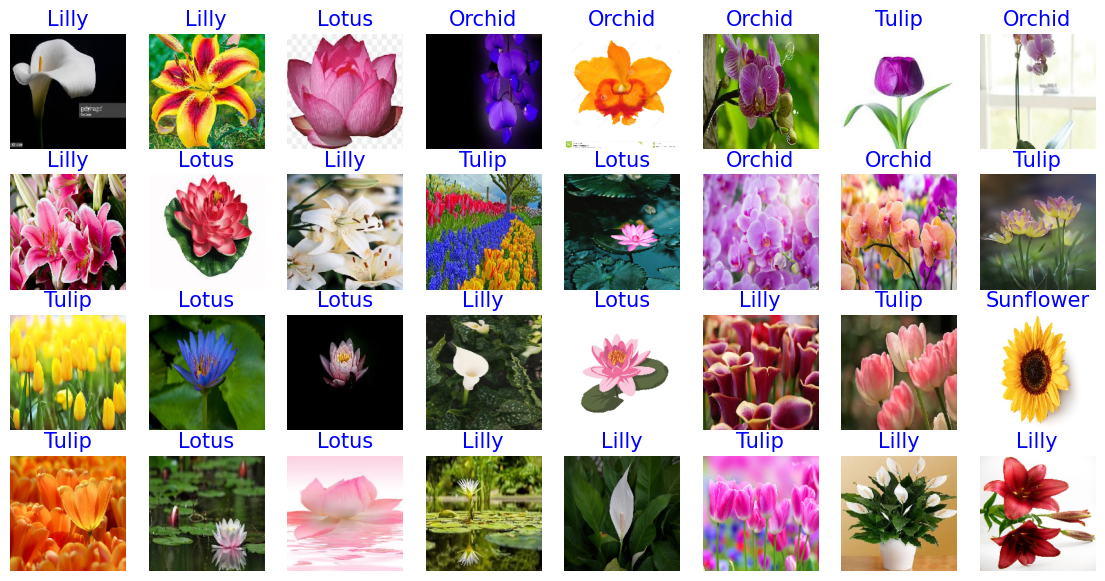

In [68]:
g_dict = train_dataset.class_indices
classes = list(g_dict.keys())
images,labels = next(train_dataset)
plt.figure(figsize=(14,7))

for i in range(32):
    plt.subplot(4,8,i+1)
    image=images[i]/255
    plt.imshow(image)
    index=np.argmax(labels[i])
    classes_name=classes[index]
    plt.title(classes_name,color="blue",fontsize=15)
    plt.axis('off')

plt.show()

## VGG16 pre-trained model

Feature extraction

In [69]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))
conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [70]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256)(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(5, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [71]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="small_vgg16_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 125ms/step - accuracy: 0.5983 - loss: 47.6619 - val_accuracy: 0.7720 - val_loss: 24.4817
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.7867 - loss: 15.9869 - val_accuracy: 0.8280 - val_loss: 15.4661
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.8435 - loss: 7.4855 - val_accuracy: 0.8240 - val_loss: 12.4149
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.8364 - loss: 6.2482 - val_accuracy: 0.8400 - val_loss: 8.7384
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.8591 - loss: 4.0903 - val_accuracy: 0.8360 - val_loss: 6.0185
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 108ms/step - accuracy: 0.8654 - loss: 3.0117 - val_accuracy: 0.8260 - val_loss: 6.5094
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.8516 - loss: 2.6267 - val_accuracy: 0.8520 - val_loss: 4.1947
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.8577 - lo

Evaluate the model on the test set

In [72]:
test_model = keras.models.load_model(
    "small_vgg16_feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.8486 - loss: 4.5011
Test accuracy: 0.854


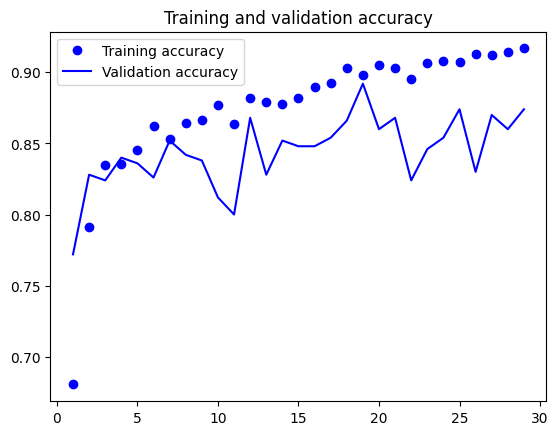

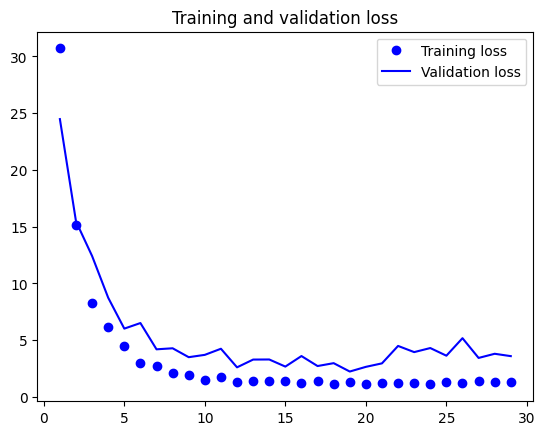

In [73]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Fine-tuning

Freezing all layers until the fourth from the last

In [74]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [75]:
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="small_vgg16_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.9323 - loss: 0.8962 - val_accuracy: 0.8880 - val_loss: 2.9159
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 132ms/step - accuracy: 0.9465 - loss: 0.5238 - val_accuracy: 0.9020 - val_loss: 2.5684
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.9587 - loss: 0.4237 - val_accuracy: 0.9200 - val_loss: 2.7317
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 131ms/step - accuracy: 0.9616 - loss: 0.4065 - val_accuracy: 0.9120 - val_loss: 2.2612
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.9650 - loss: 0.3322 - val_accuracy: 0.9240 - val_loss: 2.1501
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 127ms/step - accuracy: 0.9670 - loss: 0.3111 - val_accuracy: 0.9100 - val_loss: 2.4740
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.9727 - loss: 0.2755 - val_accuracy: 0.9220 - val_loss: 2.1819
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 129ms/step - accuracy: 0.9696 - loss: 0

In [76]:
model = keras.models.load_model("small_vgg16_fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.9183 - loss: 2.8890
Test accuracy: 0.928


**VGG16 pre-trained model gets much greater accuracy after fine-tuning (0.928) compared with the greatest result from classification models (Random Forest-0.814)**

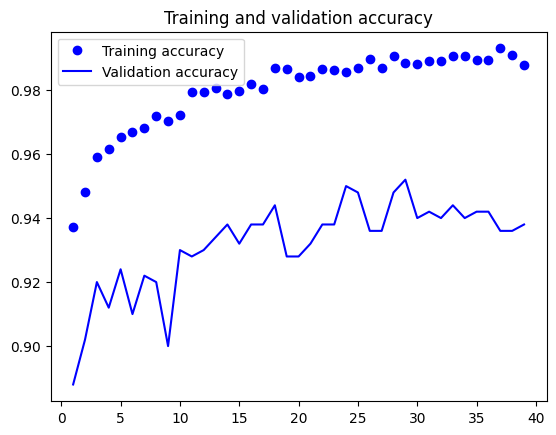

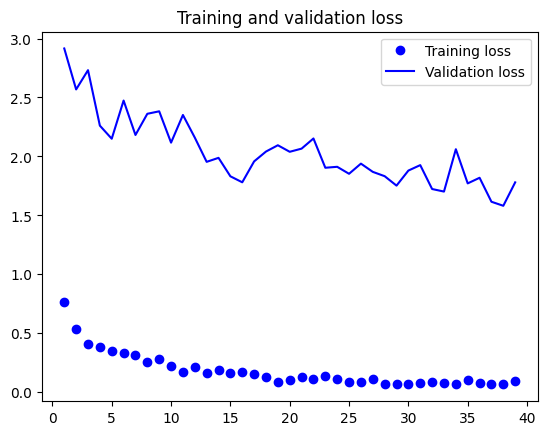

In [77]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Confusion matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step


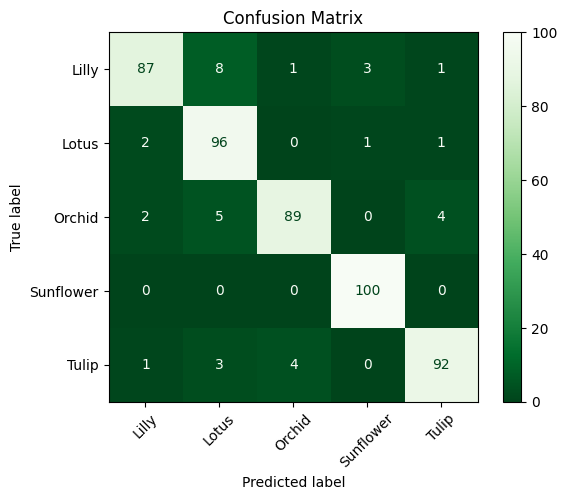

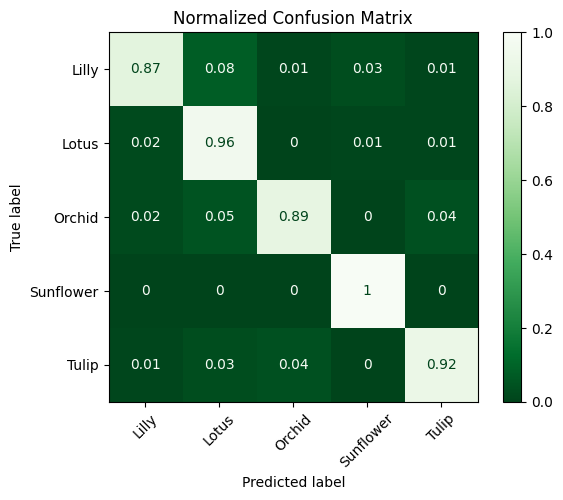

In [78]:
class_indices = test_dataset.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# Now get the correct order based on sorted keys (0, 1, 2, ...)
num_classes = len(index_to_class)
class_names = [index_to_class[i] for i in range(num_classes)]

# Predict on test dataset
predictions = model.predict(test_dataset, verbose=1)

# True labels from test dataset
true_labels = test_dataset.classes

# Predicted class indices
predicted_labels = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Plot normalized confusion matrix
cm_normalized = confusion_matrix(true_labels, predicted_labels, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()

In [79]:
print("Confusion Matrix (Raw):")
print(cm)

Confusion Matrix (Raw):
[[ 87   8   1   3   1]
 [  2  96   0   1   1]
 [  2   5  89   0   4]
 [  0   0   0 100   0]
 [  1   3   4   0  92]]


Class 0 (Liily) is the most confused with other classes, with 13/100 misclassifications in total. It seems particularly confused with Class 1 (Lotus), with 8/100 misclassifications.

Class 3 (Sunflower) is the least confused with other classes, with 0/100 misclassification in total.

## Xception pre-trained model

Feature extraction

In [80]:
conv_base = keras.applications.xception.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))
conv_base.trainable = False
conv_base.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 89, 89,    │        864 │ input_layer_3[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 89, 89,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 89, 89,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 87, 87,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 87, 87,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 87, 87,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 87, 87,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 87, 87,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 87, 87,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 87, 87,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 87, 87,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 44, 44,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 44, 44,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 44, 44,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 44, 44,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 44, 44,    │          0 │ add_1[0][0]     

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [81]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.xception.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(5, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [82]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="small_xception_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 155ms/step - accuracy: 0.5439 - loss: 4.0420 - val_accuracy: 0.7340 - val_loss: 0.6575
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 18s 140ms/step - accuracy: 0.7362 - loss: 0.7137 - val_accuracy: 0.7980 - val_loss: 0.5622
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.7666 - loss: 0.6457 - val_accuracy: 0.8080 - val_loss: 0.5329
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 133ms/step - accuracy: 0.7858 - loss: 0.5649 - val_accuracy: 0.8120 - val_loss: 0.5022
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.8070 - loss: 0.5164 - val_accuracy: 0.8380 - val_loss: 0.4982
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step - accuracy: 0.8053 - loss: 0.5131 - val_accuracy: 0.8180 - val_loss: 0.4804
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.8223 - loss: 0.5105 - val_accuracy: 0.8320 - val_loss: 0.4543
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 135ms/step - accuracy: 0.8476 - loss: 0

In [83]:
test_model = keras.models.load_model(
    "small_xception_feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.8972 - loss: 0.3044
Test accuracy: 0.902


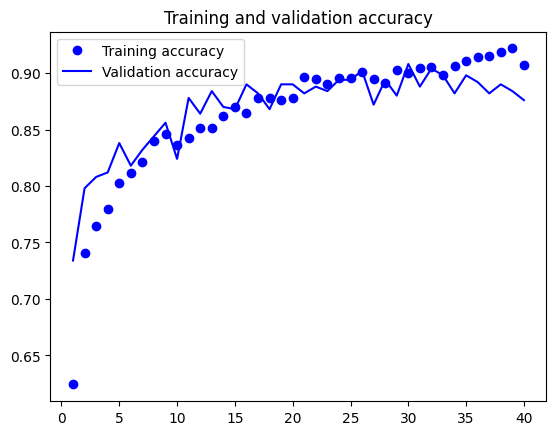

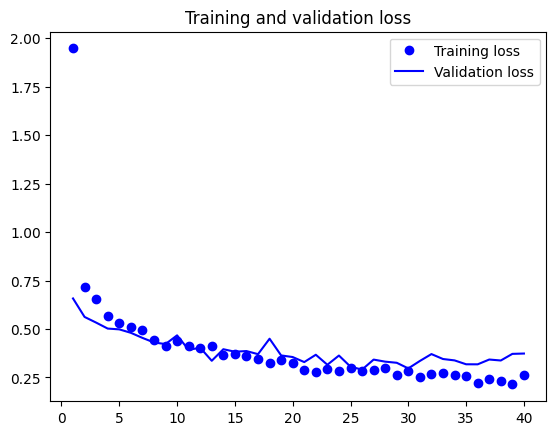

In [84]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Fine-tuning

Unfreeze only the high-level layers (from block11 onward)

In [85]:
conv_base.trainable = True
for layer in conv_base.layers[:-37]:
    layer.trainable = False

for layer in conv_base.layers[-37:]:
    if isinstance(layer, layers.BatchNormalization):  # keep BatchNorm frozen
        layer.trainable = False

In [86]:
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="small_xception_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 191ms/step - accuracy: 0.9245 - loss: 0.2111 - val_accuracy: 0.8940 - val_loss: 0.3208
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.9345 - loss: 0.1839 - val_accuracy: 0.8980 - val_loss: 0.3005
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.9415 - loss: 0.1594 - val_accuracy: 0.9080 - val_loss: 0.3294
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.9458 - loss: 0.1493 - val_accuracy: 0.9100 - val_loss: 0.3028
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 187ms/step - accuracy: 0.9532 - loss: 0.1274 - val_accuracy: 0.9140 - val_loss: 0.2989
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 185ms/step - accuracy: 0.9485 - loss: 0.1316 - val_accuracy: 0.9180 - val_loss: 0.2746
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 23s 185ms/step - accuracy: 0.9559 - loss: 0.1338 - val_accuracy: 0.9180 - val_loss: 0.2712
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.9560 - loss: 0

In [87]:
model = keras.models.load_model("small_xception_fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.9393 - loss: 0.2107
Test accuracy: 0.940


**Xception pre-trained model gives greater accuracy after fine-tuning compare with VGG16 pre-trained model**

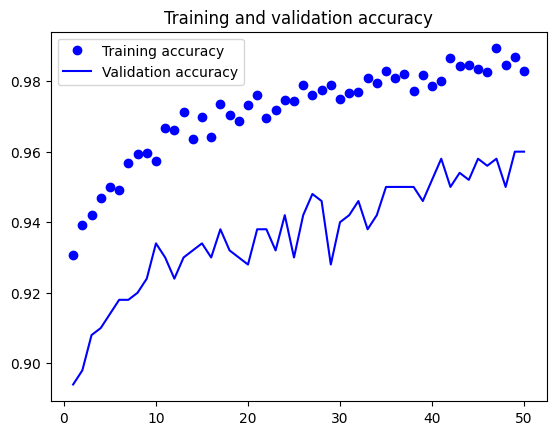

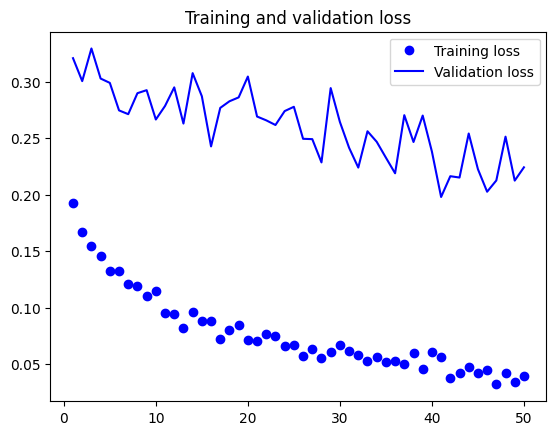

In [88]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Confusion matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step


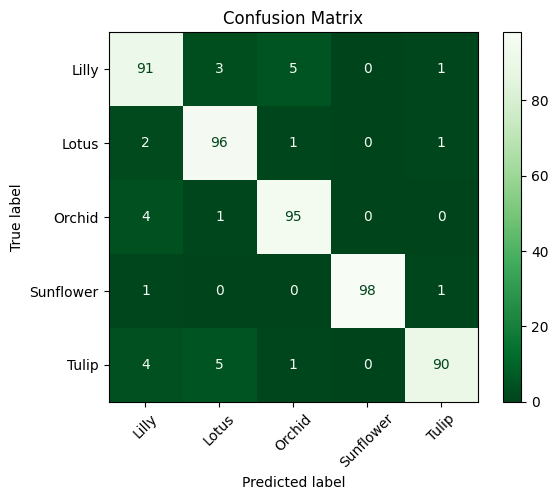

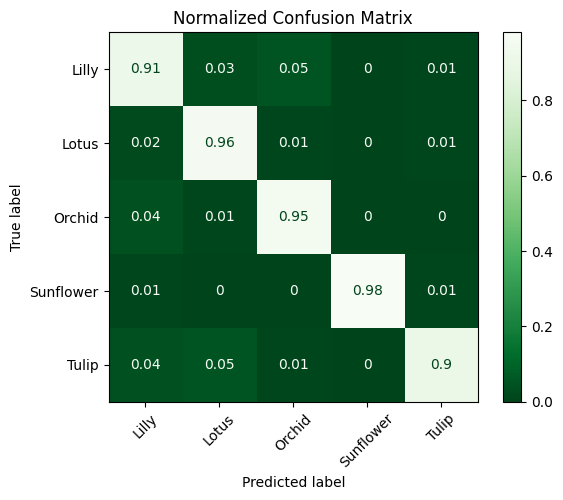

In [89]:
# Predict on test dataset
predictions = model.predict(test_dataset, verbose=1)

# True labels from test dataset
true_labels = test_dataset.classes

# Predicted class indices
predicted_labels = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Plot normalized confusion matrix
cm_normalized = confusion_matrix(true_labels, predicted_labels, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()

In [90]:
print("Confusion Matrix (Raw):")
print(cm)

Confusion Matrix (Raw):
[[91  3  5  0  1]
 [ 2 96  1  0  1]
 [ 4  1 95  0  0]
 [ 1  0  0 98  1]
 [ 4  5  1  0 90]]


Class 0 (Lilly) and class 4 (Tulip) are the most confused with other classes, with 9/100-10/100 misclassifications in total.

Class 3 (Sunflower) is the least confused with other classes, with 2/100 misclassification in total.

## EfficentNet pre-trained model

Feature extraction

In [91]:
conv_base = keras.applications.efficientnet.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))
conv_base.trainable = False
conv_base.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 180, 180,  │          0 │ input_layer_6[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 180, 180,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 180, 180,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 181, 181,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 90, 90,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 90, 90,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 90, 90,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 90, 90,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 90, 90,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 90, 90,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 90, 90,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 90, 90,    │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [92]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(5, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(loss="categorical_crossentropy",
              optimizer="adamax",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="small_efficientnet_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.6340 - loss: 1.7932 - val_accuracy: 0.8720 - val_loss: 0.3532
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 114ms/step - accuracy: 0.8659 - loss: 0.3744 - val_accuracy: 0.9140 - val_loss: 0.2556
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.8959 - loss: 0.2803 - val_accuracy: 0.9320 - val_loss: 0.2218
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.9178 - loss: 0.2328 - val_accuracy: 0.9140 - val_loss: 0.2195
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.9367 - loss: 0.1886 - val_accuracy: 0.9400 - val_loss: 0.1955
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9471 - loss: 0.1633 - val_accuracy: 0.9480 - val_loss: 0.1581
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.9597 - loss: 0.1320 - val_accuracy: 0.9480 - val_loss: 0.1586
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.9540 - loss: 0

In [93]:
test_model = keras.models.load_model(
    "small_efficientnet_feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 90ms/step - accuracy: 0.9535 - loss: 0.1832
Test accuracy: 0.964


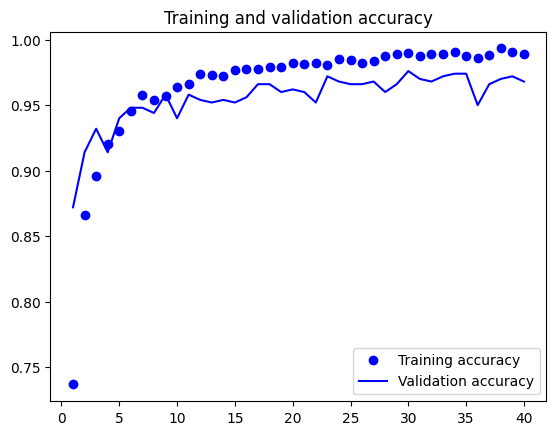

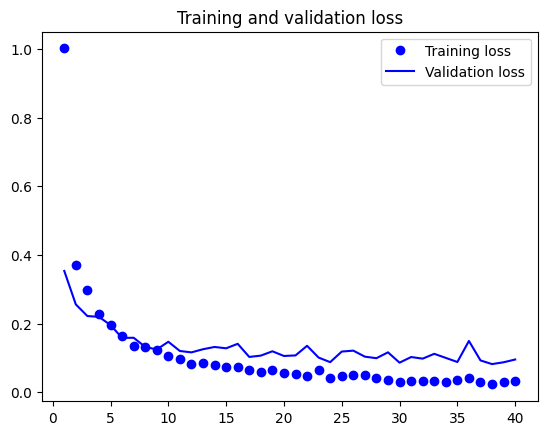

In [94]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Fine-tuning

Unfreeze only the high-level layers from block7a

In [95]:
conv_base.trainable = True
for layer in conv_base.layers[:-16]:
    layer.trainable = False

for layer in conv_base.layers[-16:]:
    if isinstance(layer, layers.BatchNormalization):  # keep BatchNorm frozen
        layer.trainable = False

In [96]:
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.Adamax(learning_rate=1e-5),
              metrics=["accuracy"])
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="small_efficientnet_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 133ms/step - accuracy: 0.9883 - loss: 0.0308 - val_accuracy: 0.9700 - val_loss: 0.0911
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 106ms/step - accuracy: 0.9917 - loss: 0.0227 - val_accuracy: 0.9700 - val_loss: 0.0911
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.9890 - loss: 0.0265 - val_accuracy: 0.9700 - val_loss: 0.0916
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.9915 - loss: 0.0323 - val_accuracy: 0.9700 - val_loss: 0.0910
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 104ms/step - accuracy: 0.9929 - loss: 0.0203 - val_accuracy: 0.9700 - val_loss: 0.0911
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.9924 - loss: 0.0195 - val_accuracy: 0.9700 - val_loss: 0.0896
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.9936 - loss: 0.0199 - val_accuracy: 0.9700 - val_loss: 0.0885
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step - accuracy: 0.9935 - loss: 0

In [97]:
model = keras.models.load_model("small_efficientnet_fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 92ms/step - accuracy: 0.9650 - loss: 0.1782
Test accuracy: 0.968


**EfficientNetB0 pre-trained model after fine-tuning gains the best result (0.968) compared with VGG16 (0.928) and Xception models (0.940).**

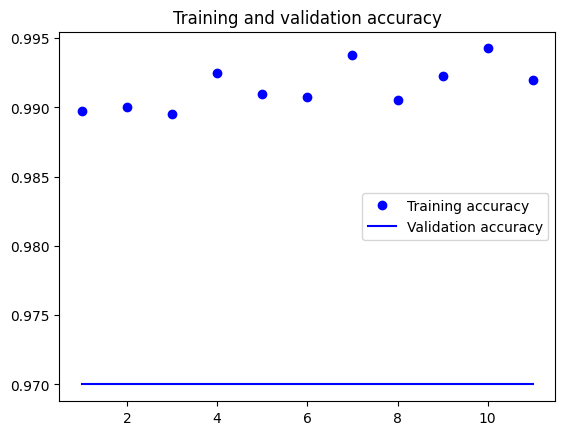

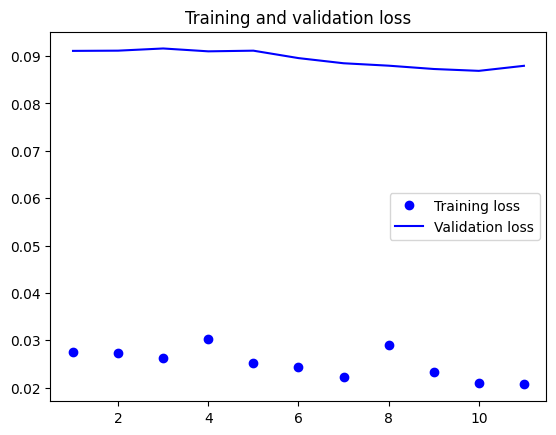

In [98]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Confusion matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 216ms/step


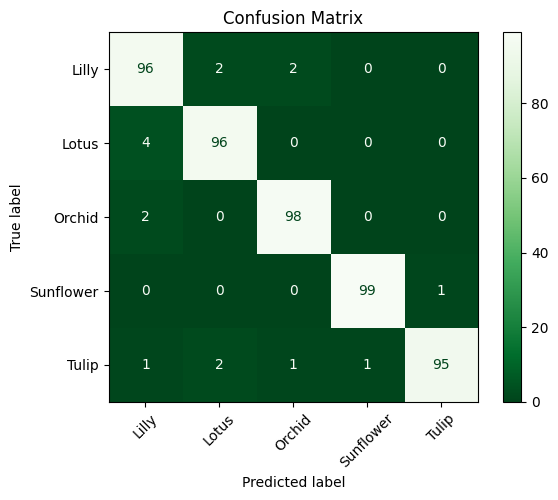

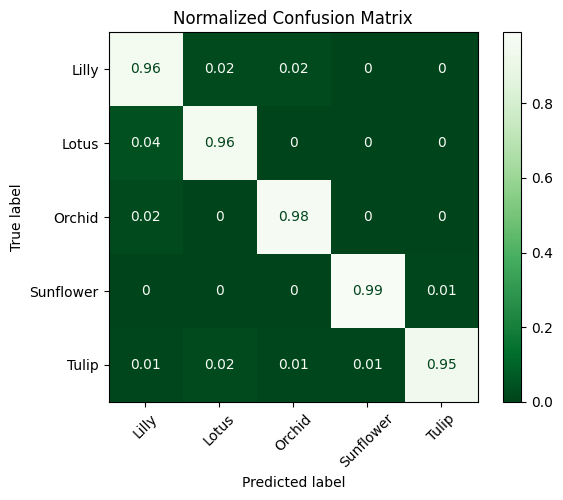

In [99]:
# Predict on test dataset
predictions = model.predict(test_dataset, verbose=1)

# True labels from test dataset
true_labels = test_dataset.classes

# Predicted class indices
predicted_labels = np.argmax(predictions, axis=1)


# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Plot normalized confusion matrix
cm_normalized = confusion_matrix(true_labels, predicted_labels, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()

In [100]:
print("Confusion Matrix (Raw):")
print(cm)

Confusion Matrix (Raw):
[[96  2  2  0  0]
 [ 4 96  0  0  0]
 [ 2  0 98  0  0]
 [ 0  0  0 99  1]
 [ 1  2  1  1 95]]


The number of misclassifications of the classes are small, with 5/100 for the most confused class (class 4-Tulip) and 1/100 for the least confused one (class 3-Sunflower).

# **Large Flower Dataset**

# Preprocessing data

Download and extract the flower datasets from TensorFlow

In [101]:
path = kagglehub.dataset_download("nadyana/flowers")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/flowers


In [102]:
import pathlib

label = []
my_path = []
datalist = os.listdir(path)

for fold in datalist:
    foldpath = os.path.join(path,fold)
    foldlist = os.listdir(foldpath)
    for file in foldlist:
        filepath = os.path.join(foldpath,file)
        print(filepath)
        imgs = os.listdir(filepath)
        for img in imgs:
            imgpath = os.path.join(filepath,img)
            label.append(file)
            my_path.append(imgpath)

l = pd.Series(label,name="labels")
p = pd.Series(my_path,name="filepath")
df = pd.concat([p,l],axis=1)
df.head()

/kaggle/input/flowers/flowers/bellflower
/kaggle/input/flowers/flowers/dandelion
/kaggle/input/flowers/flowers/daisy
/kaggle/input/flowers/flowers/sunflower
/kaggle/input/flowers/flowers/tulip
/kaggle/input/flowers/flowers/lotus
/kaggle/input/flowers/flowers/rose


,filepath,labels
0,/kaggle/input/flowers/flowers/bellflower/wild-...,bellflower
1,/kaggle/input/flowers/flowers/bellflower/dalma...,bellflower
2,/kaggle/input/flowers/flowers/bellflower/wild-...,bellflower
3,/kaggle/input/flowers/flowers/bellflower/large...,bellflower
4,/kaggle/input/flowers/flowers/bellflower/bellf...,bellflower


In [103]:
df["labels"].value_counts()

,count
labels,
bellflower,1600
dandelion,1600
daisy,1600
sunflower,1600
tulip,1600
lotus,1600
rose,1600


In [104]:
df.sample(7)

,filepath,labels
4686,/kaggle/input/flowers/flowers/daisy/3454283764...,daisy
11079,/kaggle/input/flowers/flowers/rose/bouquet-bei...,rose
9571,/kaggle/input/flowers/flowers/lotus/ca7947262d...,lotus
1201,/kaggle/input/flowers/flowers/bellflower/c57d8...,bellflower
7362,/kaggle/input/flowers/flowers/tulip/tulips-vas...,tulip
3334,/kaggle/input/flowers/flowers/daisy/daisy-2427...,daisy
3120,/kaggle/input/flowers/flowers/dandelion/211956...,dandelion


In [105]:
df.shape

(11200, 2)

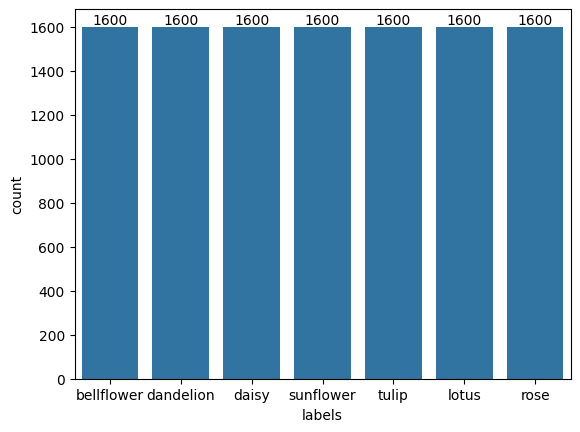

In [106]:
ax = sns.countplot(x=df['labels'])
ax.bar_label(ax.containers[0]);

In [107]:
train_df, dummy_df = train_test_split(df, train_size=0.8, random_state=42, stratify=df["labels"])
valid_df, test_df = train_test_split(dummy_df, test_size=0.5, random_state=42, stratify=dummy_df["labels"])

In [108]:
batch_size = 32
image_size = (180,180)
channels = 3
image_shape = (image_size[0], image_size[1], channels)
img_gen = ImageDataGenerator()
train_dataset = img_gen.flow_from_dataframe(train_df,x_col="filepath",y_col="labels",target_size=image_size,
                                     class_mode="categorical",
                                    color_mode="rgb",batch_size=batch_size)
validation_dataset = img_gen.flow_from_dataframe(valid_df,x_col="filepath",y_col="labels",target_size=image_size,
                                     class_mode="categorical",
                                    color_mode="rgb",batch_size=batch_size)
test_dataset = img_gen.flow_from_dataframe(test_df,x_col="filepath",y_col="labels",target_size=image_size,
                                    class_mode="categorical", shuffle=False,
                                    color_mode="rgb",batch_size=batch_size)

Found 8960 validated image filenames belonging to 7 classes.
Found 1120 validated image filenames belonging to 7 classes.
Found 1120 validated image filenames belonging to 7 classes.


In [109]:
for data_batch, labels_batch in train_dataset:
    print("data batch shape:", data_batch.shape)
    print("labels batch shape:", labels_batch.shape)
    break

data batch shape: (32, 180, 180, 3)
labels batch shape: (32, 7)


Display seven classes of flowers

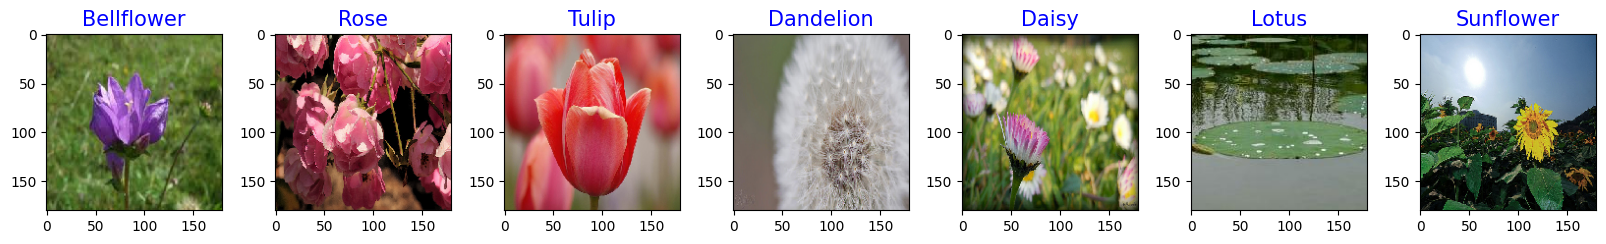

In [110]:
# Reverse class index to name
g_dict = train_dataset.class_indices
classes = list(g_dict.keys())
reverse_dict = {v: k for k, v in g_dict.items()}

# Get one image per class
images, labels = next(train_dataset)
sampled_classes = {}
for i in range(len(images)):
    class_index = np.argmax(labels[i])
    class_name = reverse_dict[class_index]
    if class_name not in sampled_classes:
        sampled_classes[class_name] = images[i] / 255.0  # normalize
    if len(sampled_classes) == 7:
        break

# Plot
plt.figure(figsize=(20, 3))
for i, (class_name, image) in enumerate(sampled_classes.items()):
    plt.subplot(1, 7, i + 1)
    plt.imshow(image)
    plt.title(class_name.capitalize(), color="blue", fontsize=15)
    plt

plt.subplots_adjust(wspace=0.3)  # adjust the value to control spacing

# Pre-trained Neural Network Models

## VGG16 pre-trained model

Feature extraction

In [111]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))
conv_base.trainable = False
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 180, 180, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 90, 90, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 90, 90, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 90, 90, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 45, 45, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 45, 45, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 45, 45, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 22, 22, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 22, 22, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 11, 11, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 11, 11, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 5, 5, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [112]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.2),
    ]
)

inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.vgg16.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(7, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
              optimizer="rmsprop",
              metrics=["accuracy"])

In [113]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="large_vgg16_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


280/280 ━━━━━━━━━━━━━━━━━━━━ 70s 246ms/step - accuracy: 0.6471 - loss: 5.9437 - val_accuracy: 0.8313 - val_loss: 0.8423
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - accuracy: 0.8203 - loss: 0.8284 - val_accuracy: 0.8598 - val_loss: 0.8129
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.8535 - loss: 0.6982 - val_accuracy: 0.8830 - val_loss: 0.7110
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - accuracy: 0.8705 - loss: 0.6404 - val_accuracy: 0.8929 - val_loss: 0.8869
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - accuracy: 0.8886 - loss: 0.5751 - val_accuracy: 0.8964 - val_loss: 0.7305
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - accuracy: 0.8942 - loss: 0.5062 - val_accuracy: 0.8875 - val_loss: 0.9593
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.9005 - loss: 0.4793 - val_accuracy: 0.8929 - val_loss: 0.8312
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.9031 - loss: 0.4813 - val

In [114]:
test_model = keras.models.load_model(
    "large_vgg16_feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 228ms/step - accuracy: 0.8781 - loss: 0.7788
Test accuracy: 0.876


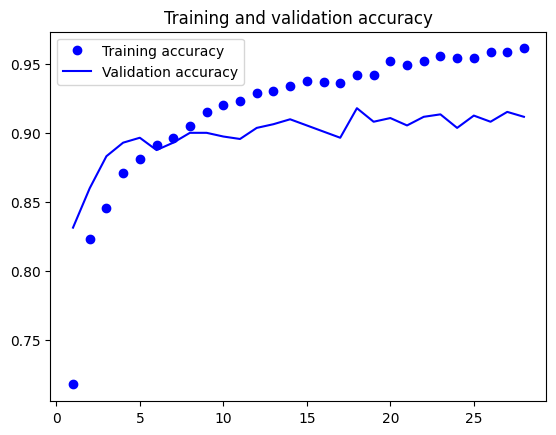

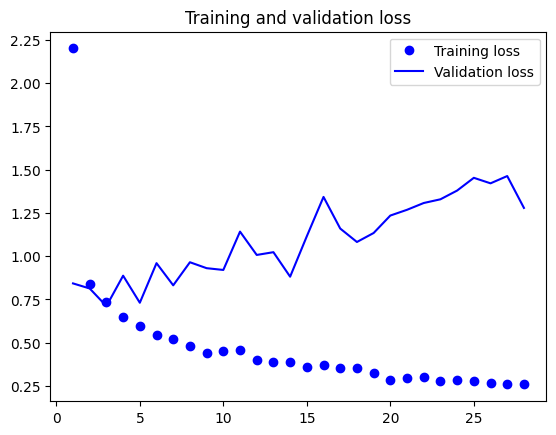

In [115]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Fine-tuning

In [116]:
conv_base.trainable = True
for layer in conv_base.layers[:-4]:
    layer.trainable = False

In [117]:
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.RMSprop(learning_rate=1e-5),
              metrics=["accuracy"])
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="large_vgg16_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 42s 142ms/step - accuracy: 0.9669 - loss: 0.1875 - val_accuracy: 0.9116 - val_loss: 1.0079
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 129ms/step - accuracy: 0.9641 - loss: 0.1920 - val_accuracy: 0.9187 - val_loss: 1.2145
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.9716 - loss: 0.1288 - val_accuracy: 0.9250 - val_loss: 1.0691
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - accuracy: 0.9688 - loss: 0.1575 - val_accuracy: 0.9187 - val_loss: 1.3269
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 130ms/step - accuracy: 0.9751 - loss: 0.1282 - val_accuracy: 0.9196 - val_loss: 1.0883
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 133ms/step - accuracy: 0.9751 - loss: 0.1184 - val_accuracy: 0.9339 - val_loss: 0.9754
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - accuracy: 0.9716 - loss: 0.1256 - val_accuracy: 0.9286 - val_loss: 1.0750
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 133ms/step - accuracy: 0.9747 - loss: 0

In [118]:
model = keras.models.load_model("large_vgg16_fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.9218 - loss: 1.1844
Test accuracy: 0.924


**VGG16 pre-trained model after fine-tuning provides close result for small (0.928) and large datasets (0.924)**

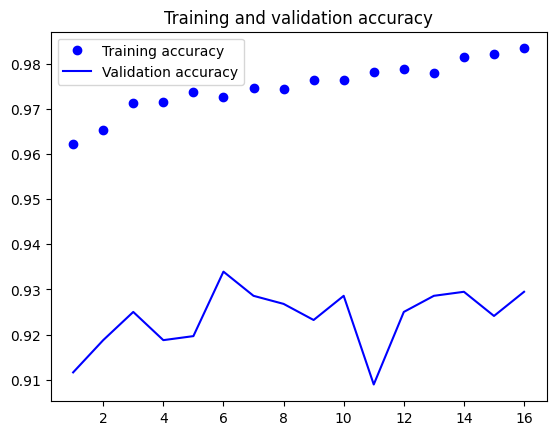

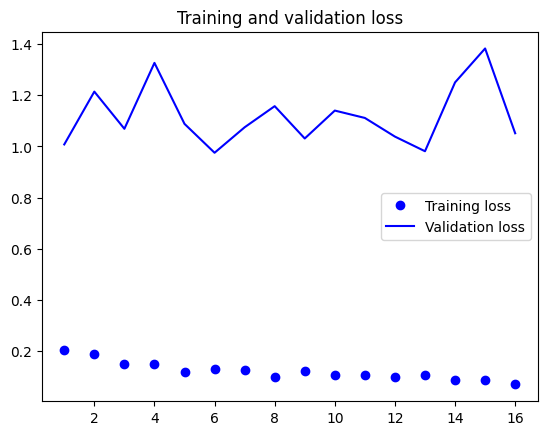

In [119]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Confusion matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step


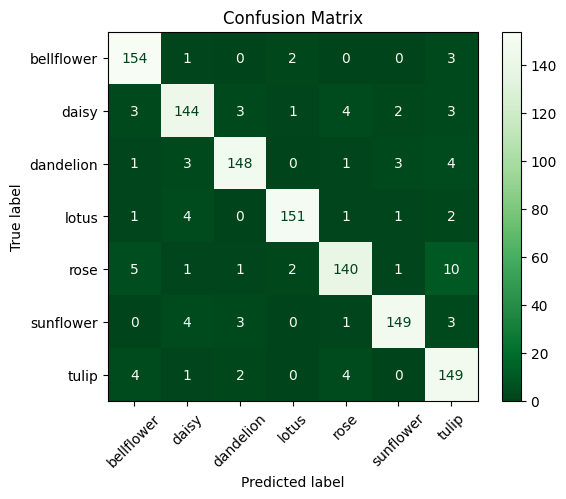

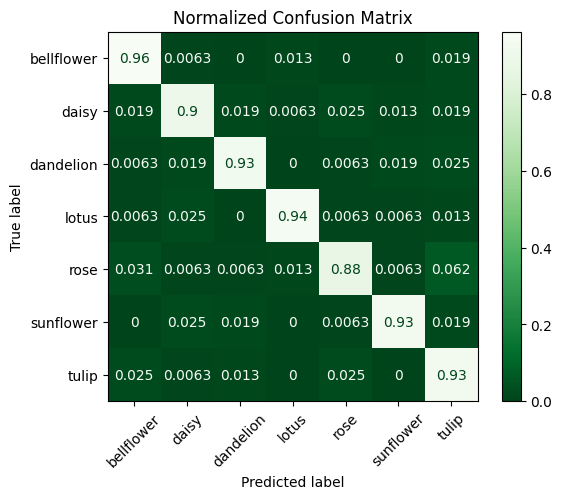

In [120]:
class_indices = test_dataset.class_indices
index_to_class = {v: k for k, v in class_indices.items()}

# Now get the correct order based on sorted keys (0, 1, 2, ...)
num_classes = len(index_to_class)
class_names = [index_to_class[i] for i in range(num_classes)]

# Predict on test dataset
predictions = model.predict(test_dataset, verbose=1)

# True labels from test dataset
true_labels = test_dataset.classes

# Predicted class indices
predicted_labels = np.argmax(predictions, axis=1)# Predict on test dataset

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Plot normalized confusion matrix
cm_normalized = confusion_matrix(true_labels, predicted_labels, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()

In [121]:
print("Confusion Matrix (Raw):")
print(cm)

Confusion Matrix (Raw):
[[154   1   0   2   0   0   3]
 [  3 144   3   1   4   2   3]
 [  1   3 148   0   1   3   4]
 [  1   4   0 151   1   1   2]
 [  5   1   1   2 140   1  10]
 [  0   4   3   0   1 149   3]
 [  4   1   2   0   4   0 149]]


Class 4 (rose) is the most confused with other classes, with 20/160 misclassifications in total. It seems particularly confused with Class 6 (tulip), with 10/160 misclassifications.

Class 0 (bellflower) is the least confused with other classes, with 6/160 misclassification in total.

## Xception pre-trained model

Feature extraction

In [122]:
conv_base = keras.applications.xception.Xception(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))
conv_base.trainable = False
conv_base.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 89, 89,    │        864 │ input_layer_11[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 89, 89,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 89, 89,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 87, 87,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 87, 87,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 87, 87,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 87, 87,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 87, 87,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 87, 87,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 87, 87,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 87, 87,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 44, 44,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 44, 44,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 44, 44,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 44, 44,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 44, 44,    │          0 │ add_14[0][0]    

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,861,480 (79.58 MB)

In [123]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.xception.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(7, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

In [124]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="large_xception_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.6672 - loss: 2.4784 - val_accuracy: 0.8232 - val_loss: 0.5182
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 134ms/step - accuracy: 0.7909 - loss: 0.6359 - val_accuracy: 0.8509 - val_loss: 0.4219
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 130ms/step - accuracy: 0.8265 - loss: 0.5314 - val_accuracy: 0.8554 - val_loss: 0.4289
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - accuracy: 0.8393 - loss: 0.4877 - val_accuracy: 0.8830 - val_loss: 0.3657
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 38s 135ms/step - accuracy: 0.8541 - loss: 0.4327 - val_accuracy: 0.8857 - val_loss: 0.3624
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 131ms/step - accuracy: 0.8540 - loss: 0.4327 - val_accuracy: 0.8705 - val_loss: 0.3843
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 36s 129ms/step - accuracy: 0.8634 - loss: 0.4007 - val_accuracy: 0.8768 - val_loss: 0.3637
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 37s 133ms/step - accuracy: 0.8668 - loss: 0

In [125]:
test_model = keras.models.load_model(
    "large_xception_feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - accuracy: 0.8596 - loss: 0.3614
Test accuracy: 0.872


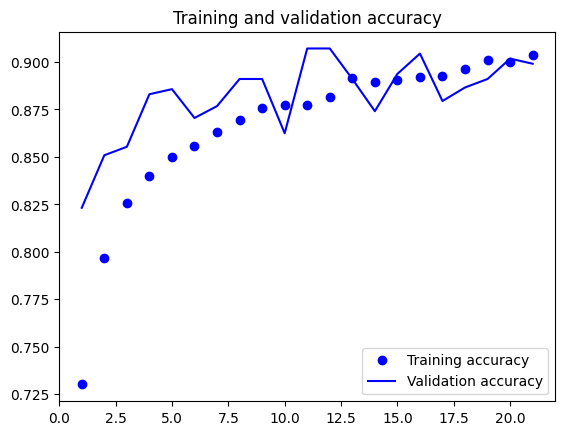

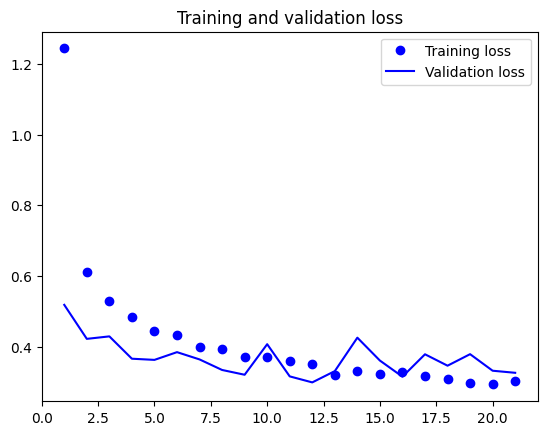

In [126]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Fine-tuning

In [127]:
# Unfreeze only the high-level layers (from block11 onward)
conv_base.trainable = True
for layer in conv_base.layers[:-37]:
    layer.trainable = False

for layer in conv_base.layers[-37:]:
    if isinstance(layer, layers.BatchNormalization):  # keep BatchNorm frozen
        layer.trainable = False

In [128]:
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              metrics=["accuracy"])
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="large_xception_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.9168 - loss: 0.2493 - val_accuracy: 0.9205 - val_loss: 0.2757
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 49s 173ms/step - accuracy: 0.9417 - loss: 0.1692 - val_accuracy: 0.9241 - val_loss: 0.2764
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 51s 182ms/step - accuracy: 0.9369 - loss: 0.1816 - val_accuracy: 0.9286 - val_loss: 0.2563
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 51s 182ms/step - accuracy: 0.9458 - loss: 0.1649 - val_accuracy: 0.9304 - val_loss: 0.2488
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 51s 183ms/step - accuracy: 0.9552 - loss: 0.1310 - val_accuracy: 0.9304 - val_loss: 0.2473
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.9579 - loss: 0.1336 - val_accuracy: 0.9304 - val_loss: 0.2505
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step - accuracy: 0.9533 - loss: 0.1337 - val_accuracy: 0.9312 - val_loss: 0.2544
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 51s 183ms/step - accuracy: 0.9582 - loss: 0

In [129]:
model = keras.models.load_model("large_xception_fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.9445 - loss: 0.2106
Test accuracy: 0.940


**Xception pre-trained model also gives greater accuracy after fine-tuning compare with VGG16 pre-trained model**

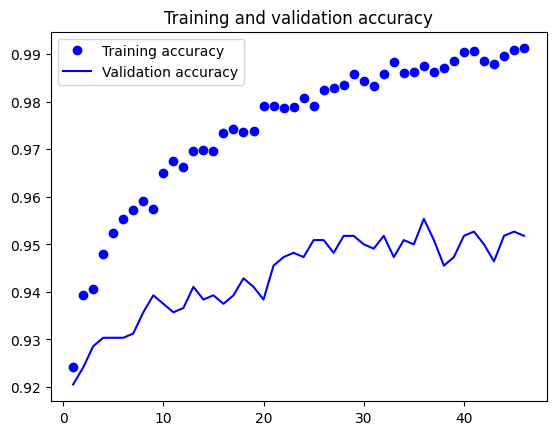

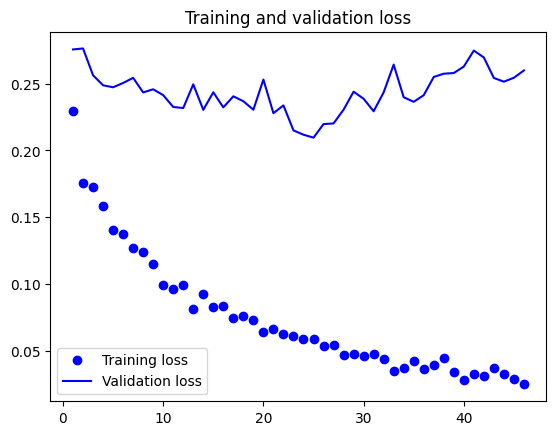

In [130]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Confusion matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step


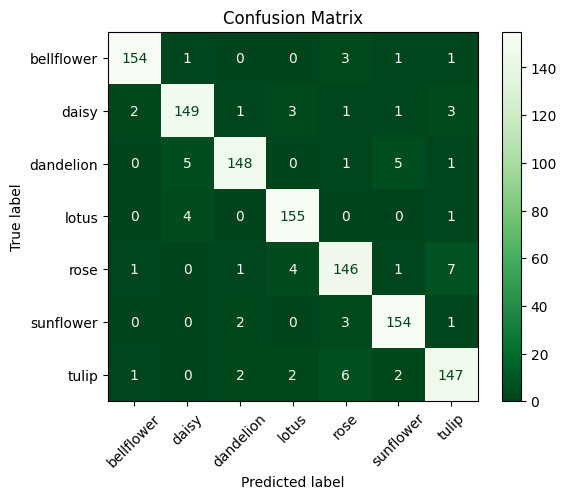

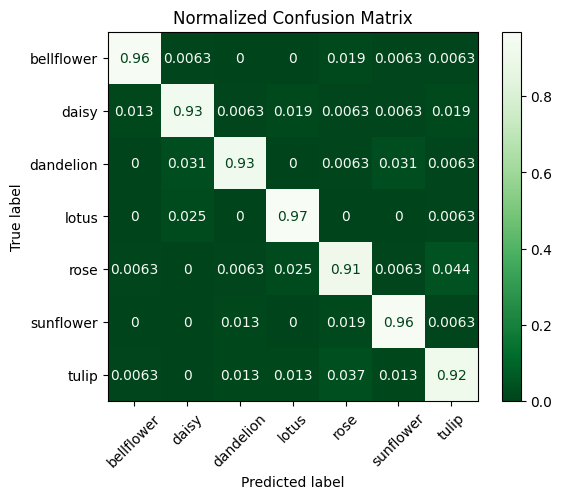

In [131]:
# Predict on test dataset
predictions = model.predict(test_dataset, verbose=1)

# True labels from test dataset
true_labels = test_dataset.classes

# Predicted class indices
predicted_labels = np.argmax(predictions, axis=1)


# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Plot normalized confusion matrix
cm_normalized = confusion_matrix(true_labels, predicted_labels, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()

In [132]:
print("Confusion Matrix (Raw):")
print(cm)

Confusion Matrix (Raw):
[[154   1   0   0   3   1   1]
 [  2 149   1   3   1   1   3]
 [  0   5 148   0   1   5   1]
 [  0   4   0 155   0   0   1]
 [  1   0   1   4 146   1   7]
 [  0   0   2   0   3 154   1]
 [  1   0   2   2   6   2 147]]


The number of misclassifications in the classes is reduced. The most confused class is still rose with 14/160 misclassifications in total, whereas the least confused class is lotus which has 5/160 misclassification in total.

### EfficentNet pre-trained model

Feature extraction

In [133]:
conv_base = keras.applications.efficientnet.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(180, 180, 3))
conv_base.trainable = False
conv_base.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 180, 180,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 180, 180,  │          0 │ input_layer_13[0… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 180, 180,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 180, 180,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 181, 181,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 90, 90,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 90, 90,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 90, 90,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 90, 90,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 90, 90,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 90, 90,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 90, 90,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 90, 90,    │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [134]:
inputs = keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = conv_base(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(7, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.compile(loss="categorical_crossentropy",
              optimizer="adamax",
              metrics=["accuracy"])

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="large_efficientnet_feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 46s 131ms/step - accuracy: 0.7581 - loss: 0.9550 - val_accuracy: 0.9089 - val_loss: 0.2982
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.9072 - loss: 0.2874 - val_accuracy: 0.9241 - val_loss: 0.2648
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - accuracy: 0.9320 - loss: 0.2079 - val_accuracy: 0.9223 - val_loss: 0.2617
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - accuracy: 0.9419 - loss: 0.1655 - val_accuracy: 0.9321 - val_loss: 0.2473
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.9512 - loss: 0.1473 - val_accuracy: 0.9312 - val_loss: 0.2472
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 119ms/step - accuracy: 0.9619 - loss: 0.1253 - val_accuracy: 0.9384 - val_loss: 0.2507
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 119ms/step - accuracy: 0.9614 - loss: 0.1028 - val_accuracy: 0.9384 - val_loss: 0.2493
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 119ms/step - accuracy: 0.9673 - loss: 0

In [135]:
test_model = keras.models.load_model(
    "large_efficientnet_feature_extraction.keras")
test_loss, test_acc = test_model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 116ms/step - accuracy: 0.9557 - loss: 0.2023
Test accuracy: 0.942


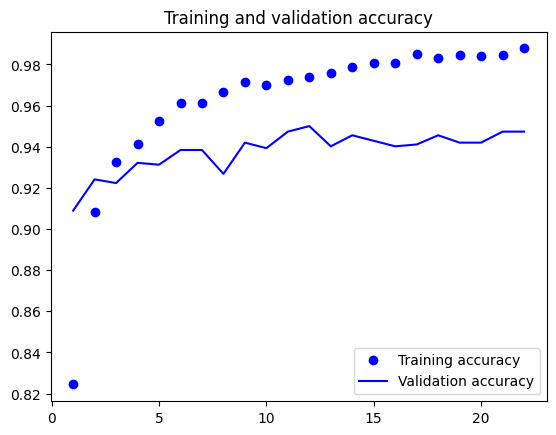

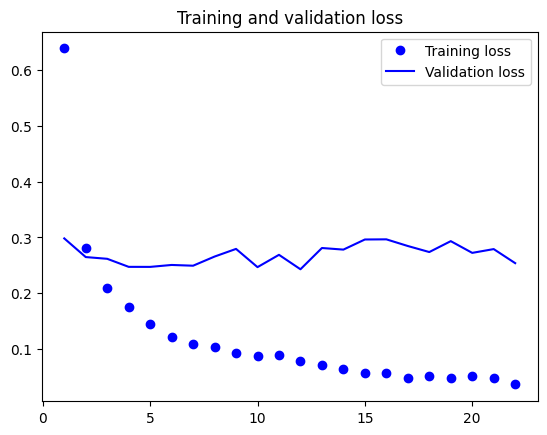

In [136]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Fine-tuning

In [137]:
# Unfreeze only the high-level layers (from block7a onward)
conv_base.trainable = True
for layer in conv_base.layers[:-16]:
    layer.trainable = False

for layer in conv_base.layers[-16:]:
    if isinstance(layer, layers.BatchNormalization):  # keep BatchNorm frozen
        layer.trainable = False

In [138]:
model.compile(loss="categorical_crossentropy",
              optimizer=keras.optimizers.Adamax(learning_rate=1e-5),
              metrics=["accuracy"])
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
    ),
    keras.callbacks.ModelCheckpoint(
        filepath="large_efficientnet_fine_tuning.keras",
        save_best_only=True,
        monitor="val_loss")
]
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=validation_dataset,
    callbacks=callbacks)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 48s 131ms/step - accuracy: 0.9884 - loss: 0.0377 - val_accuracy: 0.9482 - val_loss: 0.2565
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 120ms/step - accuracy: 0.9900 - loss: 0.0326 - val_accuracy: 0.9500 - val_loss: 0.2572
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 33s 117ms/step - accuracy: 0.9906 - loss: 0.0319 - val_accuracy: 0.9500 - val_loss: 0.2566
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 122ms/step - accuracy: 0.9880 - loss: 0.0438 - val_accuracy: 0.9491 - val_loss: 0.2597
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 121ms/step - accuracy: 0.9879 - loss: 0.0367 - val_accuracy: 0.9500 - val_loss: 0.2576
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 124ms/step - accuracy: 0.9898 - loss: 0.0296 - val_accuracy: 0.9500 - val_loss: 0.2549
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 35s 124ms/step - accuracy: 0.9885 - loss: 0.0320 - val_accuracy: 0.9509 - val_loss: 0.2530
Epoch 8/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 34s 120ms/step - accuracy: 0.9893 - loss: 0

In [139]:
model = keras.models.load_model("large_efficientnet_fine_tuning.keras")
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step - accuracy: 0.9558 - loss: 0.1789
Test accuracy: 0.949


**EfficientNetB0 pre-trained model for large dataset after fine-tuning gains better result (0.949) compared with VGG16 (0.924) and Xception pre-trained models (0.940), but the best accuracy (0.968) is from EfficientNetB0 pre-trained model for small dataset.**

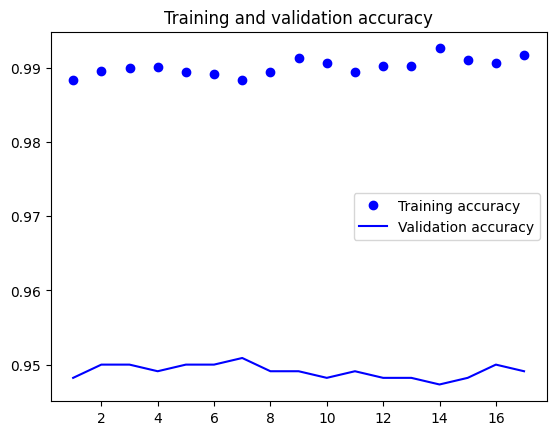

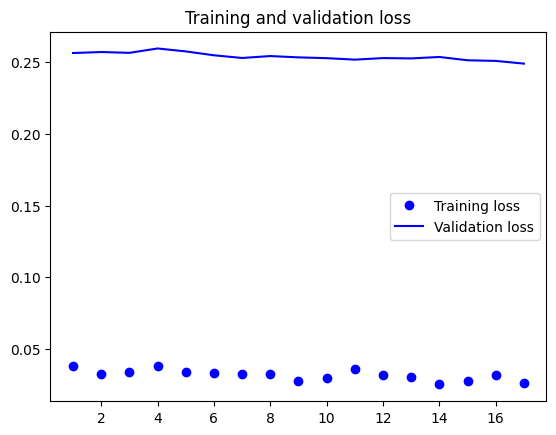

In [140]:
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

Confusion matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step


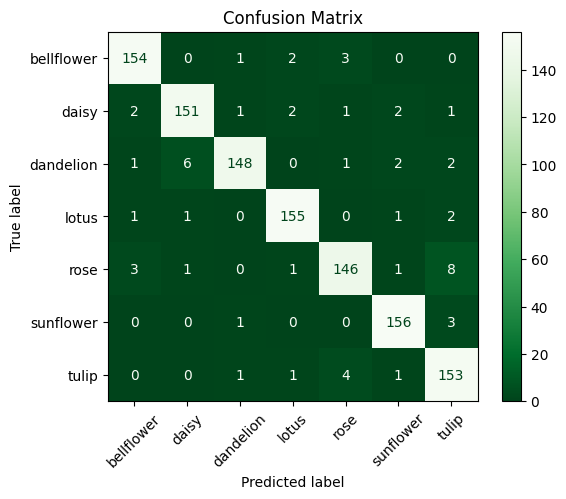

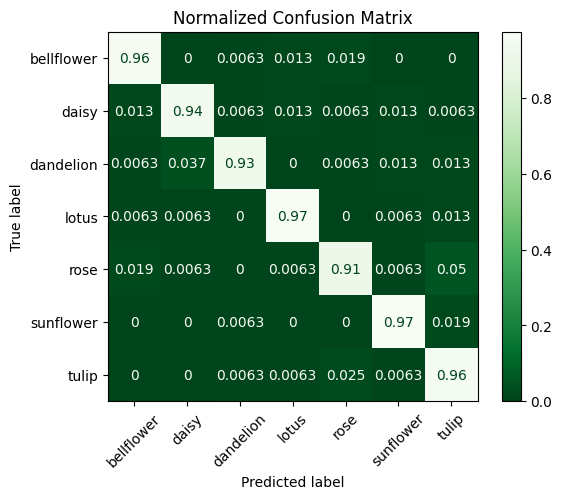

In [141]:
# Predict on test dataset
predictions = model.predict(test_dataset, verbose=1)

# True labels from test dataset
true_labels = test_dataset.classes

# Predicted class indices
predicted_labels = np.argmax(predictions, axis=1)


# Confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot raw confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Plot normalized confusion matrix
cm_normalized = confusion_matrix(true_labels, predicted_labels, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens_r', xticks_rotation=45)
plt.title("Normalized Confusion Matrix")
plt.show()

In [142]:
print("Confusion Matrix (Raw):")
print(cm)

Confusion Matrix (Raw):
[[154   0   1   2   3   0   0]
 [  2 151   1   2   1   2   1]
 [  1   6 148   0   1   2   2]
 [  1   1   0 155   0   1   2]
 [  3   1   0   1 146   1   8]
 [  0   0   1   0   0 156   3]
 [  0   0   1   1   4   1 153]]


Similarly, the most confused class is rose containing 14/160 misclassifications in total, while the least confused class is sunflower with 4/160 misclassifications in total.

# **Run Gradio**

In [143]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 6.1 MB/s eta 0:00:00


In [144]:
import gradio as gr
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load model
model = tf.keras.models.load_model("small_efficientnet_fine_tuning.keras")

def predict_image(img):
    try:
        img = keras_image.img_to_array(img)
        img = tf.image.resize(img, (180, 180))
        img = preprocess_input(img)
        img = tf.expand_dims(img, axis=0)

        prediction = model.predict(img)
        predicted_class_index = tf.argmax(prediction, axis=-1).numpy()[0]
        confidence = tf.reduce_max(prediction).numpy()

        predicted_class_name = class_names[predicted_class_index]

        return f"Predicted: {predicted_class_name} with confidence: {confidence * 100:.2f}%"

    except Exception as e:
        return f"Error: {str(e)}"

# Gradio interface
interface = gr.Interface(fn=predict_image, inputs=gr.Image(), outputs=gr.Text())
interface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://699ebaaa13641f8288.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
